# AI & ML Internship - Task 2

# House Price Prediction using Multiple Regression Models

## Objective

The objective of this project is to build, compare, and evaluate multiple regression models for predicting California house prices.

Unlike Task 1, this project introduces feature scaling and compares different machine learning algorithms to determine the best-performing model.

---

### Models Used

- Linear Regression
- Ridge Regression
- Decision Tree Regressor

---

### Workflow

1. Import Required Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Feature Scaling
5. Train-Test Split
6. Train Multiple Models
7. Compare Model Performance
8. Visualize Predictions
9. Save Best Model
10. Conclusion

# Step 1 - Import Required Libraries

In this step, we import all the libraries required for data loading, preprocessing, visualization, model training, evaluation, and model saving.

Each library serves a different purpose in the machine learning workflow.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

## Observation

All required libraries were successfully imported.

These libraries will be used throughout the project for:

- Data handling
- Data visualization
- Feature scaling
- Model training
- Model evaluation
- Saving the trained model

# Step 2 - Load the Dataset

The California Housing Dataset is provided by Scikit-Learn.

It contains housing-related information collected from California districts.

The target variable is:

**MedHouseVal** (Median House Value)

In [2]:
data = fetch_california_housing(as_frame=True)

df = pd.concat(
    [data.data, data.target.rename("HousePrice")],
    axis=1
)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Observation

The dataset has been loaded successfully.

The first five rows display the available input features and the target variable.

The target variable has been renamed to **HousePrice** for better readability.

In [3]:
df.shape

(20640, 9)

## Observation

The dataset shape tells us the number of rows and columns.

- Rows represent individual housing records.
- Columns represent features along with the target variable.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Observation

The dataset contains only numerical features.

No categorical columns are present.

This simplifies preprocessing because no encoding techniques are required.

In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Observation

The statistical summary provides:

- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles

These statistics help understand the distribution of each feature.

In [6]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

## Observation

No missing values are present in the dataset.

Therefore, no data cleaning or imputation is required before training the models.

# Step 3 - Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the characteristics of the dataset before training machine learning models.

In this section, we will:

- Analyze feature relationships
- Visualize correlations
- Observe feature distributions
- Identify patterns that may influence house prices

In [7]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
HousePrice,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


## Observation

The correlation matrix shows how strongly each feature is related to every other feature.

Correlation values range between **-1 and +1**.

- Values close to **+1** indicate a strong positive relationship.
- Values close to **-1** indicate a strong negative relationship.
- Values close to **0** indicate little or no linear relationship.

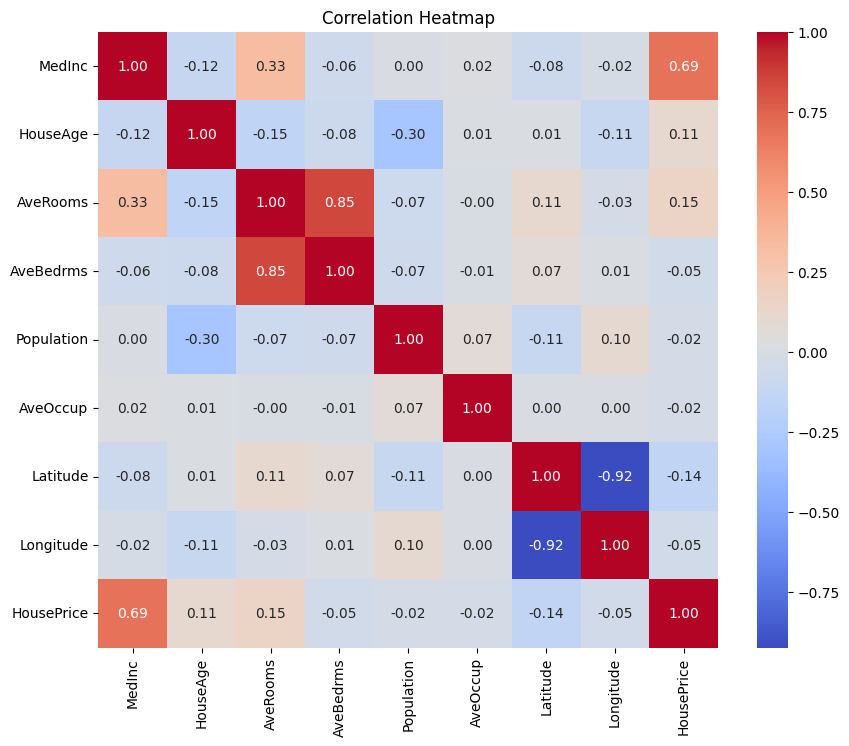

In [8]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Observation

The heatmap provides a visual representation of feature correlations.

Some observations include:

- **Median Income (MedInc)** has one of the strongest positive correlations with house prices.
- Latitude and Longitude also influence housing prices.
- Population-related features exhibit weaker relationships with the target variable.

These insights help understand which features contribute more to prediction.

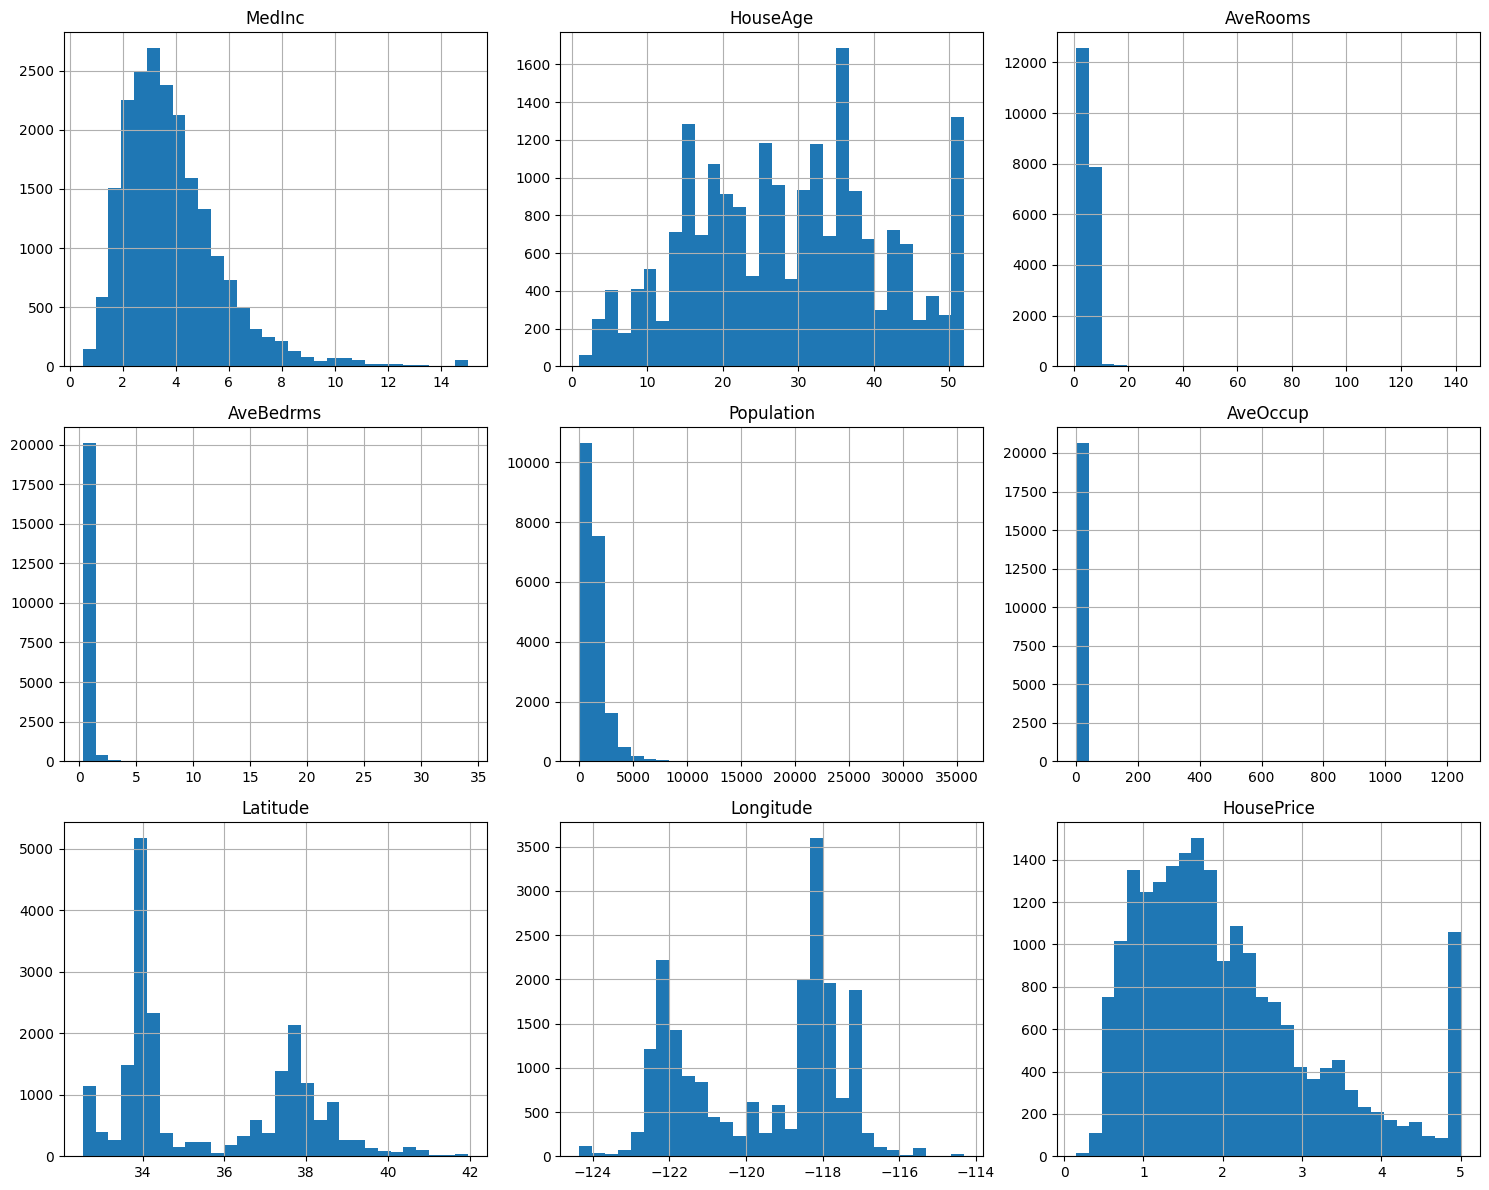

In [9]:
df.hist(figsize=(15,12), bins=30)

plt.tight_layout()

plt.show()

## Observation

Histograms display the distribution of each feature.

Some variables are approximately normally distributed, while others show skewness.

Understanding feature distributions helps in selecting suitable preprocessing techniques and machine learning models.

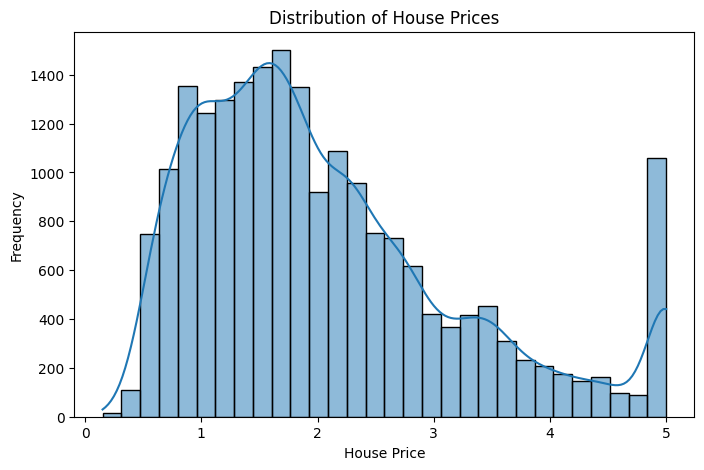

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["HousePrice"], bins=30, kde=True)

plt.title("Distribution of House Prices")

plt.xlabel("House Price")

plt.ylabel("Frequency")

plt.show()

## Observation

The distribution of house prices indicates how frequently different price ranges occur.

The target variable is not perfectly normally distributed and shows some skewness.

Understanding the target distribution is useful for evaluating model performance.

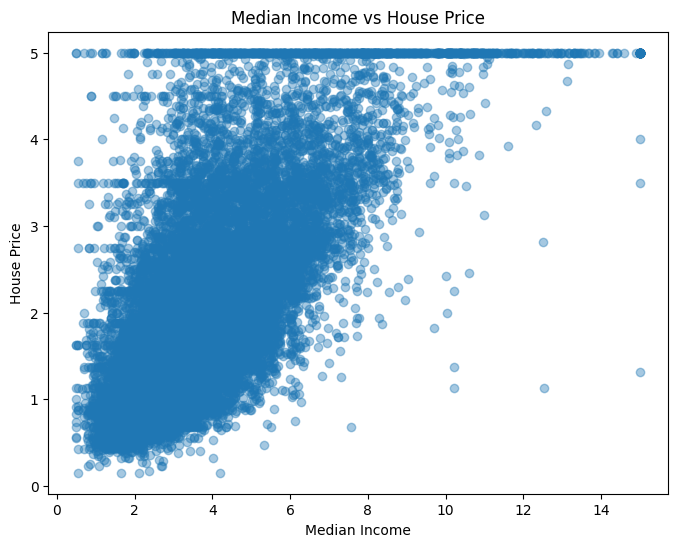

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["MedInc"],
    df["HousePrice"],
    alpha=0.4
)

plt.xlabel("Median Income")

plt.ylabel("House Price")

plt.title("Median Income vs House Price")

plt.show()

## Observation

The scatter plot suggests a positive relationship between **Median Income** and **House Price**.

As median income increases, house prices generally tend to increase.

Although the relationship is not perfectly linear, Median Income appears to be one of the most influential features in predicting house prices.

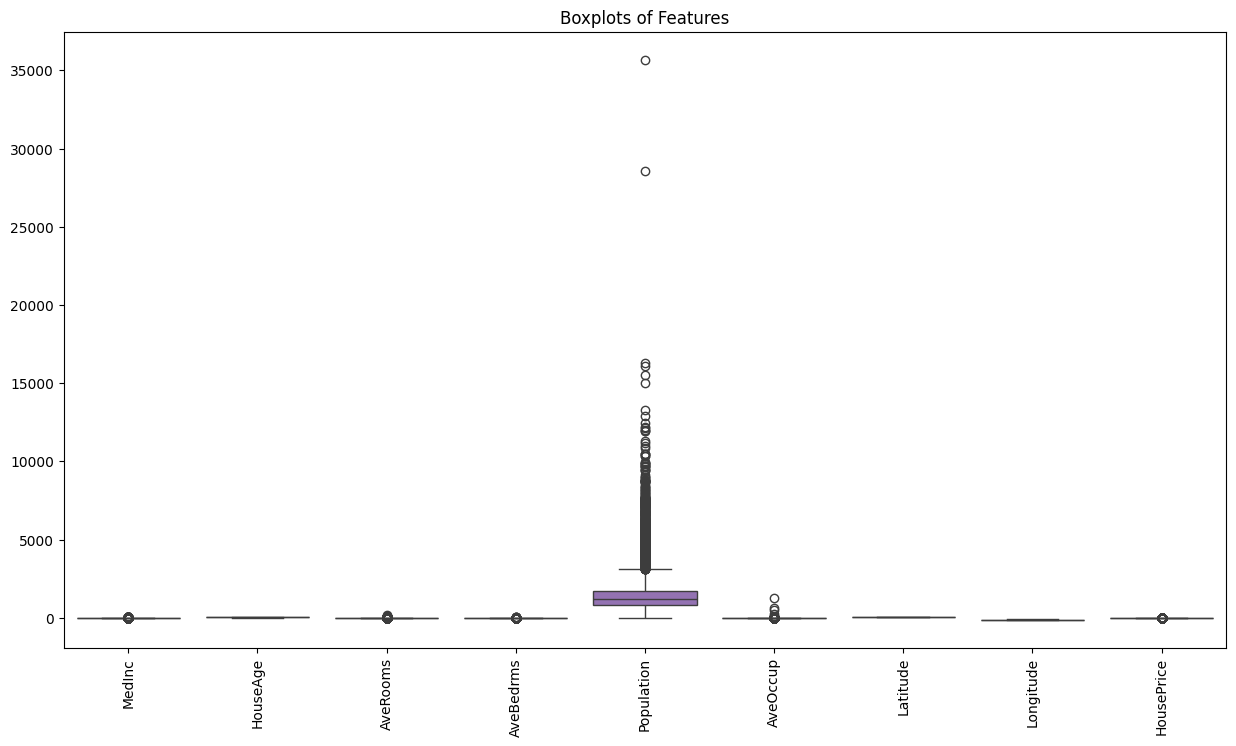

In [12]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title("Boxplots of Features")

plt.show()

## Observation

The boxplots help identify potential outliers in the dataset.

Some features contain values that lie far from the median.

Since this project focuses on model comparison, no outlier removal is performed.

# EDA Summary

From the exploratory analysis, we observed:

- The dataset contains only numerical features.
- No missing values are present.
- Median Income has a strong positive relationship with house prices.
- Feature distributions vary across variables.
- Some outliers are present.
- The dataset is suitable for regression analysis after feature scaling.

# Step 4 - Feature Scaling

Machine learning models often perform better when all input features are on a similar scale.

Since the California Housing dataset contains features with different numerical ranges, we apply **StandardScaler** to standardize the feature values.

Feature scaling improves learning stability and helps algorithms converge more efficiently.

In [13]:
X = df.drop("HousePrice", axis=1)

y = df["HousePrice"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (20640, 8)
Target Shape: (20640,)


## Observation

The dataset has been divided into:

- **X (Features):** Independent variables used for prediction.
- **y (Target):** HousePrice, which is the value we want the model to predict.

In [14]:
scaler = StandardScaler()

## Observation

A StandardScaler object has been created.

This object will calculate the mean and standard deviation of each feature and use them to standardize the data.

In [15]:
X_scaled = scaler.fit_transform(X)

## Observation

The feature data has been standardized.

Each feature now has approximately:

- Mean = 0
- Standard Deviation = 1

This ensures that no feature dominates the learning process due to differences in scale.

In [16]:
scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

scaled_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818


## Observation

The scaled dataset contains transformed feature values.

Unlike the original dataset, these values are centered around zero with unit variance.

The transformed values will now be used for model training.

In [17]:
print("Feature Means:\n")
print(scaled_df.mean())

print("\n")

print("Feature Standard Deviations:\n")
print(scaled_df.std())

Feature Means:

MedInc        5.508083e-17
HouseAge      4.406467e-17
AveRooms      7.711317e-17
AveBedrms    -1.005225e-16
Population   -1.101617e-17
AveOccup      0.000000e+00
Latitude      2.247298e-15
Longitude    -8.603626e-15
dtype: float64


Feature Standard Deviations:

MedInc        1.000024
HouseAge      1.000024
AveRooms      1.000024
AveBedrms     1.000024
Population    1.000024
AveOccup      1.000024
Latitude      1.000024
Longitude     1.000024
dtype: float64


## Observation

The calculated means are approximately zero, and the standard deviations are approximately one.

This confirms that feature scaling has been successfully applied using StandardScaler.

# Feature Scaling Summary

Feature scaling is an important preprocessing step for many machine learning algorithms.

Benefits include:

- Prevents features with large numerical ranges from dominating the model.
- Improves training stability.
- Leads to more reliable model performance.
- Makes model comparison fair across different algorithms.

The standardized dataset is now ready for train-test splitting and model training.

# Step 5 - Train-Test Split

Before training machine learning models, the dataset is divided into training and testing sets.

- **Training Set (80%)** is used to train the models.
- **Testing Set (20%)** is used to evaluate model performance on unseen data.

This helps measure how well the model generalizes to new data.

A fixed `random_state` is used to ensure reproducible results.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

## Observation

The dataset has been successfully divided into training and testing sets.

The training data will be used to train machine learning models, while the testing data will be reserved for evaluating their predictive performance.

Using unseen data helps determine how well the models generalize.

In [19]:
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print()

print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)

Training Features Shape : (16512, 8)
Testing Features Shape  : (4128, 8)

Training Target Shape   : (16512,)
Testing Target Shape    : (4128,)


## Observation

The dataset has been split successfully.

- **16,512 samples** are available for training.
- **4,128 samples** are reserved for testing.

The feature matrix contains **8 input features**, while the target variable contains the corresponding house prices.

In [20]:
pd.DataFrame(
    X_train,
    columns=X.columns
).head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,-0.321654,0.346478,-0.166259,-0.190451,0.772251,0.059808,-1.367976,1.267645
1,-0.030620,1.617807,-0.386181,-0.117472,-0.098440,-0.128306,-0.871699,0.703627
2,0.150349,-1.957806,0.087641,-0.235400,-0.450778,-0.033453,-0.455012,-0.454356
3,-1.014947,0.584852,-0.576442,-0.132670,-0.006602,0.088940,-1.377340,1.227714
4,-0.166583,1.141059,0.339282,0.079205,-0.486983,-0.074203,0.537543,-0.114948


## Observation

The displayed samples represent standardized training data.

These scaled feature values will be used to train the regression models in the next step.

# Train-Test Split Summary

The data has been successfully prepared for machine learning.

Key points:

- Features were standardized using StandardScaler.
- The dataset was divided into training and testing sets.
- The training set will be used to build the models.
- The testing set will be used for unbiased performance evaluation.

The dataset is now ready for training multiple regression models.

# Step 6 - Model Training

In this step, multiple regression models are trained using the standardized training data.

The following models are used:

- Linear Regression
- Ridge Regression
- Decision Tree Regressor

Each model will be evaluated using the same testing dataset to ensure a fair comparison.

In [21]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

## Observation

A dictionary has been created to store all regression models.

Using a dictionary allows us to train and evaluate multiple models efficiently without writing repetitive code.

In [22]:
results = []

## Observation

An empty list has been created to store the evaluation metrics of each model.

The results collected here will later be converted into a comparison table.

In [23]:
for name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Predict on test data
    predictions = model.predict(X_test)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    # Store results
    results.append([name, mae, rmse, r2])

    # Print results
    print(f"\n{name}")
    print("-" * 30)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


Linear Regression
------------------------------
MAE  : 0.5332
RMSE : 0.7456
R²   : 0.5758

Ridge Regression
------------------------------
MAE  : 0.5332
RMSE : 0.7456
R²   : 0.5758

Decision Tree
------------------------------
MAE  : 0.4531
RMSE : 0.7022
R²   : 0.6237


## Observation

All three regression models were successfully trained and evaluated.

The evaluation metrics provide a quantitative measure of each model's predictive performance.

These results will be compared to identify the most suitable model for this dataset.

In [24]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R² Score"]
)

results_df

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.533200,0.745581,0.575788
1,Ridge Regression,0.533193,0.745554,0.575819
2,Decision Tree,0.453147,0.702173,0.623746


## Observation

The comparison table summarizes the performance of all trained models.

Lower MAE and RMSE values indicate smaller prediction errors, while a higher R² Score indicates better predictive performance.

In [25]:
results_df.sort_values(
    by="R² Score",
    ascending=False
)

,Model,MAE,RMSE,R² Score
2,Decision Tree,0.453147,0.702173,0.623746
1,Ridge Regression,0.533193,0.745554,0.575819
0,Linear Regression,0.533200,0.745581,0.575788


## Observation

The models have been sorted based on their R² Score.

The model at the top of the table demonstrates the strongest predictive performance on the testing dataset.

In [26]:
best_model = results_df.sort_values(
    by="R² Score",
    ascending=False
).iloc[0]

print("=" * 50)
print("🏆 Best Performing Model")
print("=" * 50)

print(f"Model      : {best_model['Model']}")
print(f"MAE        : {best_model['MAE']:.4f}")
print(f"RMSE       : {best_model['RMSE']:.4f}")
print(f"R² Score   : {best_model['R² Score']:.4f}")

🏆 Best Performing Model
Model      : Decision Tree
MAE        : 0.4531
RMSE       : 0.7022
R² Score   : 0.6237


# Model Comparison Summary

Three regression models were trained and evaluated using the same training and testing datasets.

### Models Compared

- Linear Regression
- Ridge Regression
- Decision Tree Regressor

### Evaluation Metrics

The models were evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

### Best Performing Model

Based on the evaluation results, the **Decision Tree Regressor** achieved the highest R² Score and the lowest prediction errors among the three models.

**Performance**

- **MAE:** 0.4531
- **RMSE:** 0.7022
- **R² Score:** 0.6237

Therefore, the Decision Tree Regressor was selected as the final model for this project.

# Step 7 - Visualizing Model Performance

Visualizations help us understand how well the selected model predicts house prices.

In this section, we will:

- Generate predictions using the best-performing model.
- Compare actual and predicted house prices.
- Analyze prediction errors using a residual plot.

In [27]:
best_model_name = best_model["Model"]

best_model_object = models[best_model_name]

## Observation

The best-performing model has been retrieved from the dictionary of trained models.

This model will now be used for visualization and saving.

In [28]:
best_predictions = best_model_object.predict(X_test)

## Observation

Predictions have been generated for the testing dataset using the selected regression model.

These predictions will now be compared with the actual house prices.

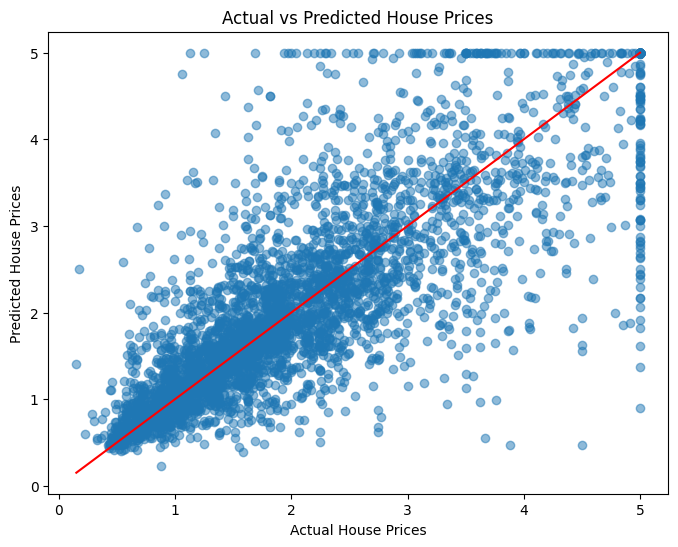

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

## Observation

The scatter plot compares the actual and predicted house prices.

Points closer to the red diagonal line indicate more accurate predictions.

The Decision Tree Regressor demonstrates reasonably good predictive performance.

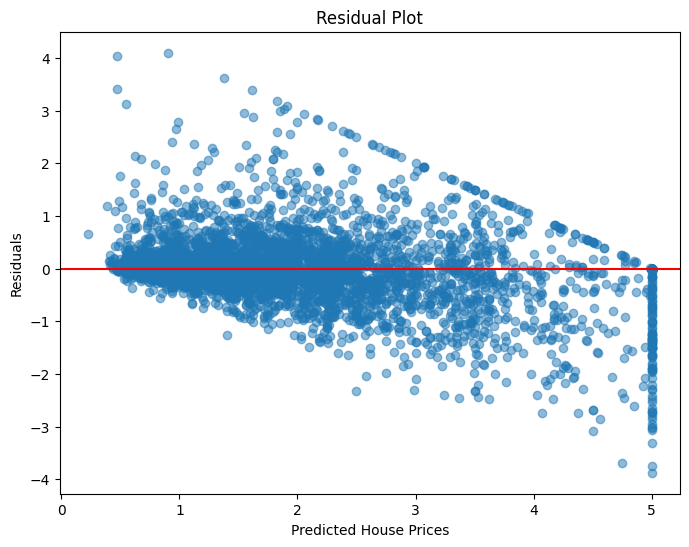

In [30]:
residuals = y_test - best_predictions

plt.figure(figsize=(8,6))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel("Predicted House Prices")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

## Observation

Residuals represent the difference between actual and predicted values.

A good regression model produces residuals that are randomly scattered around zero without any clear pattern.

The residual plot helps identify systematic prediction errors.

# Step 8 - Saving the Best Model

After comparing all regression models, the Decision Tree Regressor was selected as the final model.

Saving the trained model allows it to be reused later without retraining.

In [31]:
joblib.dump(
    best_model_object,
    "best_house_price_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


## Observation

The trained Decision Tree model has been saved as:

**best_house_price_model.pkl**

This saved model can be loaded later to make predictions on new data without repeating the training process.

In [32]:
loaded_model = joblib.load(
    "best_house_price_model.pkl"
)

print(type(loaded_model))

<class 'sklearn.tree._classes.DecisionTreeRegressor'>


## Observation

The saved model was successfully loaded from disk.

This confirms that the model has been stored correctly and is ready for future predictions or deployment.

# Project Conclusion

In this project, multiple regression models were developed and compared for predicting California house prices.

## Models Evaluated

- Linear Regression
- Ridge Regression
- Decision Tree Regressor

After evaluating all models using MAE, RMSE, and R² Score, the **Decision Tree Regressor** achieved the best performance.

### Best Model Performance

- **Model:** Decision Tree Regressor
- **MAE:** 0.4531
- **RMSE:** 0.7022
- **R² Score:** 0.6237

The trained model was successfully saved using Joblib and is ready for future predictions or deployment.

This project demonstrates the complete machine learning workflow, including data preprocessing, feature scaling, model training, model comparison, evaluation, visualization, and model persistence.

In [33]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [34]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'AI_ML_Task2_Model_Comparison.ipynb', 'app.py', 'best_house_price_model.pkl', 'scaler.pkl', 'venv']
